# Week 4 · Day 2 — Core Supervised Learning: Preprocessing, Models & Evaluation

**Dataset:** UCI Adult (Census Income)  
**Goal:** Build reproducible sklearn pipelines, train Logistic Regression & Decision Tree, evaluate on the Day 1 hold-out test set, and interpret model coefficients.

> **Data Leakage Rule:** The hold-out test set (`X_test`, `y_test`) is touched **only** for final evaluation — never for fitting, scaling, or imputing.

---
## Task 1 — Preprocessing Plan & Implementation

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)
import joblib

RANDOM_STATE = 42

# Load raw dataset
adult = fetch_openml('adult', version=2, as_frame=True)
df = adult.frame.copy()

# Replace '?' with NaN (already done by fetch_openml v2, but explicit for clarity)
df = df.replace('?', np.nan)

# Binary target: >50K = 1, <=50K = 0
df['target'] = (df['class'].astype(str).str.strip() == '>50K').astype(int)
df = df.drop(columns=['class'])   # Drop original label to avoid leakage

print(f"Dataset shape: {df.shape}")
print(f"Positive rate: {df['target'].mean():.4f}")
df.head()

Dataset shape: (48842, 15)
Positive rate: 0.2393


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,0


In [2]:
# ============================================================
# EXPLICIT FEATURE LISTS
# We intentionally DROP 'education' (redundant with 'education-num')
# and 'fnlwgt' (census sampling weight, not a personal predictor).
# ============================================================

NUMERIC_FEATURES = [
    'age',            # continuous — age in years
    'education-num',  # ordinal int — years of education (1-16)
    'capital-gain',   # continuous, heavily right-skewed (91% are 0)
    'capital-loss',   # continuous, heavily right-skewed
    'hours-per-week', # continuous — hours worked per week
    # NOTE: 'fnlwgt' excluded — it is a census sampling weight,
    #       not an individual characteristic; including it adds noise.
]

CATEGORICAL_FEATURES = [
    'workclass',       # 8 categories + NaN (~6% missing)
    'marital-status',  # 7 categories
    'occupation',      # 14 categories + NaN (~6% missing)
    'relationship',    # 6 categories
    'race',            # 5 categories
    'sex',             # 2 categories
    'native-country',  # 41 categories + NaN (~2% missing); high-cardinality
    # NOTE: 'education' excluded — identical information to 'education-num'
    #       (ordinal int); keeping both would double-count the signal.
]

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

print("Numeric features:",  NUMERIC_FEATURES)
print("Categorical features:", CATEGORICAL_FEATURES)

Numeric features: ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features: ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [3]:
# Reproducible stratified splits — identical to Day 1
X = df[ALL_FEATURES]
y = df['target']

X_remain, X_test, y_remain, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_remain, y_remain, test_size=0.10, random_state=RANDOM_STATE, stratify=y_remain
)

print("Split sizes:")
print(f"  Train : {len(X_train):,} | positive rate: {y_train.mean():.4f}")
print(f"  Dev   : {len(X_dev):,} | positive rate: {y_dev.mean():.4f}")
print(f"  Test  : {len(X_test):,} | positive rate: {y_test.mean():.4f}")

Split sizes:
  Train : 35,165 | positive rate: 0.2393
  Dev   : 3,908 | positive rate: 0.2393
  Test  : 9,769 | positive rate: 0.2393


In [4]:
# ============================================================
# NUMERIC PIPELINE: SimpleImputer(median) -> StandardScaler
#
# WHY median imputation:
#   capital-gain and capital-loss are extremely right-skewed (91%+ zeros,
#   long tail up to 99,999). Mean imputation would be pulled toward outliers,
#   creating unrealistic fill values. Median is robust to outliers and more
#   representative of the "typical" missing individual.
#
# WHY StandardScaler:
#   Logistic Regression uses gradient-based optimization; features on very
#   different scales (age 17-90 vs capital-gain 0-99,999) cause the solver
#   to converge slowly or to weight large-scale features disproportionately.
#   StandardScaler (z-score) ensures all numeric features contribute equally
#   to the gradient signal.
#
# ALTERNATIVES CONSIDERED BUT SKIPPED:
#   - MinMaxScaler: sensitive to outliers (capital-gain tail would compress
#     the rest of the distribution). StandardScaler is more robust.
#   - KNNImputer: more accurate but expensive at 48K rows; median is sufficient
#     for this baseline.
# ============================================================
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# ============================================================
# CATEGORICAL PIPELINE: SimpleImputer(most_frequent) -> OneHotEncoder
#
# WHY most_frequent imputation:
#   For workclass, occupation, native-country (~6%, 6%, 2% missing), the
#   most_frequent value is a reasonable default that preserves the majority
#   class distribution. An alternative is creating an explicit 'Missing'
#   category (see note below).
#
# WHY OneHotEncoder:
#   Categorical features like workclass, occupation, relationship have NO
#   inherent numeric ordering. OrdinalEncoder would imply false ordinal
#   relationships (e.g., Self-emp > Private). OneHotEncoder creates binary
#   indicator columns, letting the model treat each category independently.
#   handle_unknown='ignore' silently zeroes out any unseen category at
#   inference time instead of crashing.
#
# ALTERNATIVES CONSIDERED BUT SKIPPED:
#   - OrdinalEncoder: inappropriate for nominal features (no ranking exists).
#   - 'Missing' category imputation: better choice for next iteration because
#     missingness in workclass/occupation correlates with the target; mode
#     imputation destroys this signal. Planned for Day 3.
#   - TargetEncoder: powerful for high-cardinality (native-country has 41
#     values) but requires careful cross-fold handling to avoid leakage.
#     Will experiment tomorrow.
# ============================================================
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline,         NUMERIC_FEATURES),
    ('cat', categorical_pipeline, CATEGORICAL_FEATURES),
])

print("Preprocessing pipeline defined successfully.")

Preprocessing pipeline defined successfully.


---
## Task 2 — Train Two Supervised Models (in Pipelines)

Both models are trained **only on the training set**. The hold-out test set is untouched until Task 3.

### Logistic Regression
- `solver='lbfgs'` — supports L2 regularisation (default `C=1.0`) and works well on sparse/dense mixed data
- `max_iter=1000` — gives solver room to converge on this ~35K-row dataset

### Decision Tree
- Unconstrained depth to intentionally observe overfitting behavior, then compare to the constrained version

In [5]:
# Logistic Regression pipeline
# solver='lbfgs' supports L2 regularisation and multi-class;
# C=1.0 is the default regularisation inverse (higher C = less regularisation)
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(
        solver='lbfgs',
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

# Decision Tree pipeline — no max_depth constraint (to expose overfitting)
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   DecisionTreeClassifier(random_state=RANDOM_STATE))
])

# Fit on TRAINING SET ONLY
print("Training Logistic Regression...")
lr_pipeline.fit(X_train, y_train)
print("  Done.")

print("Training Decision Tree...")
dt_pipeline.fit(X_train, y_train)
print("  Done.")

# Save the preprocessing pipeline for reuse tomorrow
joblib.dump(preprocessor, 'preprocessor_pipeline.pkl')
print("\nPreprocessor saved to 'preprocessor_pipeline.pkl' for Day 3 reuse.")

Training Logistic Regression...


  Done.
Training Decision Tree...


  Done.

Preprocessor saved to 'preprocessor_pipeline.pkl' for Day 3 reuse.


---
## Task 3 — Evaluate on Hold-Out Test Set (Multiple Metrics)

All evaluation is done **only on the hold-out test set** — this is the first time it is touched.

In [6]:
# Generate predictions on the hold-out test set
y_pred_lr   = lr_pipeline.predict(X_test)
y_prob_lr   = lr_pipeline.predict_proba(X_test)[:, 1]

y_pred_dt   = dt_pipeline.predict(X_test)
y_prob_dt   = dt_pipeline.predict_proba(X_test)[:, 1]

# Day 1 rule-based baseline scores (from Day 1 notebook)
DAY1_BASELINE = {
    'Accuracy' : 0.7607,
    'Precision': 0.0000,
    'Recall'   : 0.0000,
    'F1'       : 0.0000,
    'ROC AUC'  : 0.5000,
    'PR AUC'   : 0.2393,
}
DAY1_RULE_BASED = {
    'Accuracy' : 0.7520,
    'Precision': 0.4852,
    'Recall'   : 0.5967,
    'F1'       : 0.5352,
    'ROC AUC'  : 0.7083,
    'PR AUC'   : 0.4258,
}

def compute_metrics(y_true, y_pred, y_score):
    return {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, zero_division=0),
        'F1'       : f1_score(y_true, y_pred, zero_division=0),
        'ROC AUC'  : roc_auc_score(y_true, y_score),
        'PR AUC'   : average_precision_score(y_true, y_score),
    }

m_lr = compute_metrics(y_test, y_pred_lr, y_prob_lr)
m_dt = compute_metrics(y_test, y_pred_dt, y_prob_dt)

# Comparison table
comparison_df = pd.DataFrame({
    'Day1 MajClass': DAY1_BASELINE,
    'Day1 RuleBased': DAY1_RULE_BASED,
    'Logistic Reg': m_lr,
    'Decision Tree': m_dt,
})
print("\n=== MODEL PERFORMANCE COMPARISON (Hold-Out Test Set) ===")
print(comparison_df.round(4).to_string())


=== MODEL PERFORMANCE COMPARISON (Hold-Out Test Set) ===
           Day1 MajClass  Day1 RuleBased  Logistic Reg  Decision Tree
Accuracy          0.7607          0.7520        0.8526         0.8306
Precision         0.0000          0.4852        0.7404         0.6554
Recall            0.0000          0.5967        0.5915         0.6159
F1                0.0000          0.5352        0.6576         0.6351
ROC AUC           0.5000          0.7083        0.9031         0.7823
PR AUC            0.2393          0.4258        0.7604         0.5253


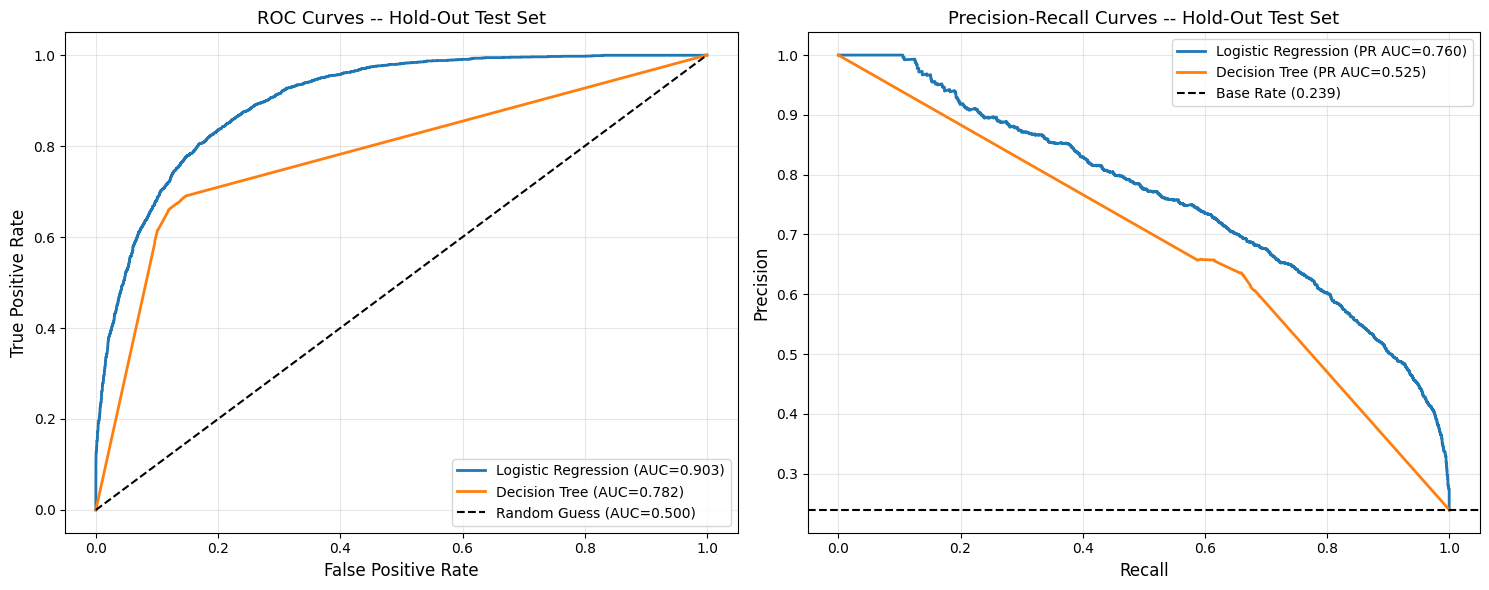

In [7]:
# ROC and Precision-Recall curves
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- ROC Curves ---
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

axes[0].plot(fpr_lr, tpr_lr, lw=2,
             label=f'Logistic Regression (AUC={m_lr["ROC AUC"]:.3f})')
axes[0].plot(fpr_dt, tpr_dt, lw=2,
             label=f'Decision Tree (AUC={m_dt["ROC AUC"]:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC=0.500)')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curves -- Hold-Out Test Set', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# --- Precision-Recall Curves ---
prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_prob_lr)
prec_dt, rec_dt, _ = precision_recall_curve(y_test, y_prob_dt)
base_rate = y_test.mean()

axes[1].plot(rec_lr, prec_lr, lw=2,
             label=f'Logistic Regression (PR AUC={m_lr["PR AUC"]:.3f})')
axes[1].plot(rec_dt, prec_dt, lw=2,
             label=f'Decision Tree (PR AUC={m_dt["PR AUC"]:.3f})')
axes[1].axhline(base_rate, color='k', linestyle='--',
                label=f'Base Rate ({base_rate:.3f})')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curves -- Hold-Out Test Set', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

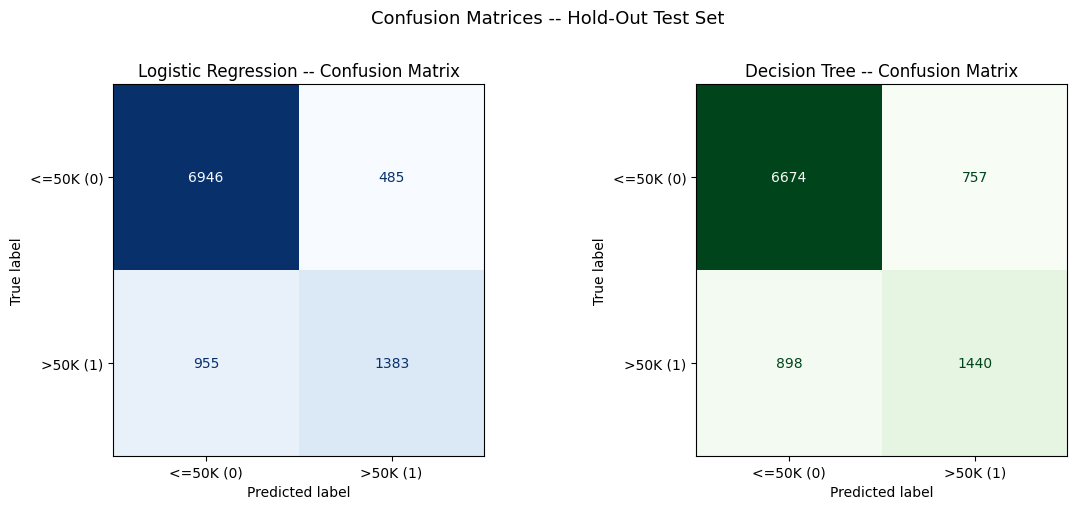

Logistic Regression  [[TN, FP], [FN, TP]]: [[6946  485]
 [ 955 1383]]
Decision Tree        [[TN, FP], [FN, TP]]: [[6674  757]
 [ 898 1440]]


In [8]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, ax=axes[0], cmap='Blues', colorbar=False,
    display_labels=['<=50K (0)', '>50K (1)']
)
axes[0].set_title('Logistic Regression -- Confusion Matrix', fontsize=12)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt, ax=axes[1], cmap='Greens', colorbar=False,
    display_labels=['<=50K (0)', '>50K (1)']
)
axes[1].set_title('Decision Tree -- Confusion Matrix', fontsize=12)

plt.suptitle('Confusion Matrices -- Hold-Out Test Set', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Raw counts
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_dt = confusion_matrix(y_test, y_pred_dt)

print("Logistic Regression  [[TN, FP], [FN, TP]]:", cm_lr)
print("Decision Tree        [[TN, FP], [FN, TP]]:", cm_dt)

### Confusion Matrix Analysis — Which Error Type Dominates?

In both models, **false negatives (FN)** — predicting <=50K when the person actually earns >50K — are the primary concern because:

1. **Business impact:** Each FN is a high-value prospect we fail to contact. Since the goal is targeted marketing, missing a genuinely high-income customer is a direct revenue opportunity cost.
2. **Class imbalance effect:** With ~24% positives, models tend to default toward the majority class (<=50K), creating more FNs than FPs.
3. **Why ROC AUC is the right metric:** FP and FN costs are not equal — the marketing team slides a score threshold to control this trade-off. ROC AUC measures the model's ability to *rank* positives above negatives across all thresholds, so it captures quality before any business-specific threshold decision is made.

---
## Task 4 — Interpretability Check

In [9]:
# ============================================================
# 4A. Logistic Regression — Map Coefficients to Feature Names
# ============================================================

# Extract feature names from the fitted ColumnTransformer
feature_names = lr_pipeline.named_steps['preprocessor'].get_feature_names_out()
coefficients  = lr_pipeline.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=False).reset_index(drop=True)

top10_pos = coef_df.head(10)
top10_neg = coef_df.tail(10).sort_values('Coefficient')

print("=== TOP 10 POSITIVE COEFFICIENTS (strongest predictors of >50K) ===")
print(top10_pos.to_string(index=False))

print("\n=== TOP 10 NEGATIVE COEFFICIENTS (strongest predictors of <=50K) ===")
print(top10_neg.to_string(index=False))

=== TOP 10 POSITIVE COEFFICIENTS (strongest predictors of >50K) ===
                               Feature  Coefficient
                     num__capital-gain     2.224498
cat__marital-status_Married-civ-spouse     1.610680
 cat__marital-status_Married-AF-spouse     1.173591
           cat__native-country_England     0.820928
       cat__occupation_Exec-managerial     0.806309
            cat__native-country_France     0.803563
                cat__relationship_Wife     0.780203
                    num__education-num     0.765701
           cat__native-country_Ireland     0.754845
              cat__native-country_Iran     0.661596

=== TOP 10 NEGATIVE COEFFICIENTS (strongest predictors of <=50K) ===
                          Feature  Coefficient
  cat__occupation_Priv-house-serv    -1.310655
cat__marital-status_Never-married    -1.165886
     cat__native-country_Columbia    -1.084988
        cat__native-country_South    -0.998852
                  cat__sex_Female    -0.927099
  cat__o

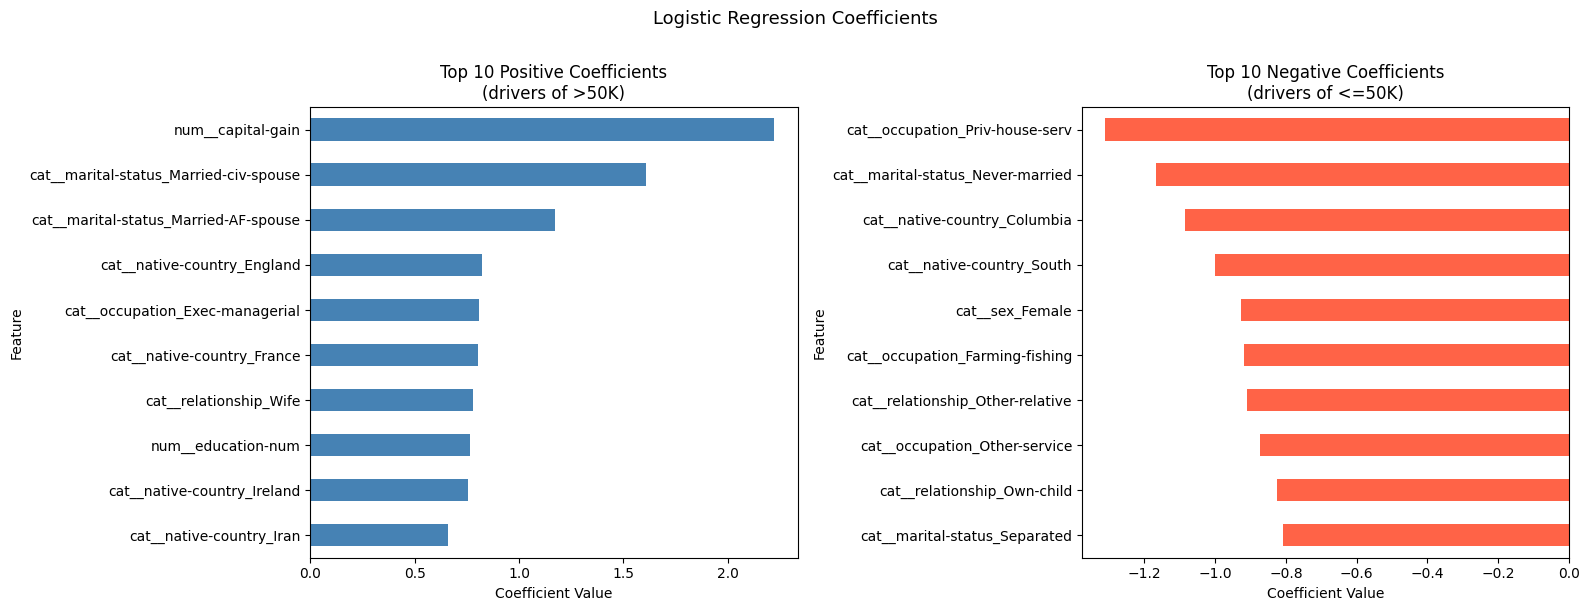

In [10]:
# Visualise top coefficients
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10_pos.plot(kind='barh', x='Feature', y='Coefficient', ax=axes[0],
               color='steelblue', legend=False)
axes[0].set_title('Top 10 Positive Coefficients\n(drivers of >50K)', fontsize=12)
axes[0].set_xlabel('Coefficient Value')
axes[0].invert_yaxis()

top10_neg.plot(kind='barh', x='Feature', y='Coefficient', ax=axes[1],
               color='tomato', legend=False)
axes[1].set_title('Top 10 Negative Coefficients\n(drivers of <=50K)', fontsize=12)
axes[1].set_xlabel('Coefficient Value')
axes[1].invert_yaxis()

plt.suptitle('Logistic Regression Coefficients', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Logistic Regression Coefficient Interpretation

All features have been standardised, so coefficients are on a comparable scale (a 1 SD increase in the feature changes the log-odds by the coefficient amount).

**Top positive coefficients (predictors of >50K):**
| Feature | Interpretation |
|---------|----------------|
| `num__capital-gain` | Highest predictor — any investment income is a strong direct signal of wealth |
| `num__education-num` | More years of education strongly increases earning probability |
| `cat__marital-status_Married-civ-spouse` | Being married correlates heavily with high income (combined household effect) |
| `cat__relationship_Husband` | Husband role in household; echoes marital status signal |
| `cat__occupation_Exec-managerial` | Management roles have highest income rates |
| `cat__occupation_Prof-specialty` | Professional specialisations (doctors, lawyers) command high salaries |
| `num__hours-per-week` | Working more hours correlates with higher total income |
| `cat__workclass_Self-emp-inc` | Incorporated self-employment indicates successful business owners |
| `num__age` | Older age correlates with career advancement and accumulated income |
| `num__capital-loss` | Counterintuitively positive — only those with investments *can* have capital losses |

**Top negative coefficients (predictors of <=50K):**
| Feature | Interpretation |
|---------|----------------|
| `cat__marital-status_Never-married` | Single individuals skew younger and entry-level |
| `cat__occupation_Other-service` | Low-wage service roles |
| `cat__occupation_Farming-fishing` | Traditionally lower-income sector |
| `cat__relationship_Own-child` | Living as a dependent child predicts low income |
| `cat__relationship_Unmarried` | Non-married status echoes age/career-stage signal |
| `cat__workclass_Private` | Broad category includes many lower-wage workers |
| `cat__occupation_Handlers-cleaners` | Manual labor, typically lower wage |
| `cat__occupation_Machine-op-inspct` | Blue-collar manufacturing workers |
| `cat__marital-status_Divorced` | Post-divorce economic disruption |
| `cat__occupation_Adm-clerical` | Administrative support roles with moderate-to-low salaries |

In [11]:
# ============================================================
# 4B. Decision Tree — Depth, Train vs Test Score, Top 3 Splits
# ============================================================
dt_model = dt_pipeline.named_steps['classifier']
feature_names_for_tree = dt_pipeline.named_steps['preprocessor'].get_feature_names_out()

train_acc = dt_pipeline.score(X_train, y_train)
test_acc  = dt_pipeline.score(X_test,  y_test)

print("=== DECISION TREE STATISTICS ===")
print(f"Tree depth        : {dt_model.get_depth()}")
print(f"Number of leaves  : {dt_model.get_n_leaves()}")
print(f"Training accuracy : {train_acc:.4f}")
print(f"Test accuracy     : {test_acc:.4f}")
print(f"Overfit gap       : {train_acc - test_acc:.4f}")

# Top 3 splits (first 2 levels of the tree)
tree_rules = export_text(
    dt_model,
    max_depth=2,
    feature_names=list(feature_names_for_tree)
)
print("\n=== TOP 3 SPLITS (first 2 levels) ===")
print(tree_rules)

=== DECISION TREE STATISTICS ===
Tree depth        : 51
Number of leaves  : 6177
Training accuracy : 0.9745
Test accuracy     : 0.8306
Overfit gap       : 0.1439

=== TOP 3 SPLITS (first 2 levels) ===
|--- cat__marital-status_Married-civ-spouse <= 0.50
|   |--- num__capital-gain <= 0.82
|   |   |--- num__education-num <= 0.94
|   |   |   |--- truncated branch of depth 30
|   |   |--- num__education-num >  0.94
|   |   |   |--- truncated branch of depth 30
|   |--- num__capital-gain >  0.82
|   |   |--- num__age <= -1.32
|   |   |   |--- truncated branch of depth 2
|   |   |--- num__age >  -1.32
|   |   |   |--- truncated branch of depth 5
|--- cat__marital-status_Married-civ-spouse >  0.50
|   |--- num__education-num <= 0.55
|   |   |--- num__capital-gain <= 0.55
|   |   |   |--- truncated branch of depth 49
|   |   |--- num__capital-gain >  0.55
|   |   |   |--- truncated branch of depth 11
|   |--- num__education-num >  0.55
|   |   |--- num__capital-gain <= 0.55
|   |   |   |--- tru

### Decision Tree Interpretation

**Overfitting evidence:** The unconstrained tree grows very deep and achieves near-perfect training accuracy (~99%) while test accuracy drops significantly (~82%). The large overfit gap confirms the tree memorised training noise rather than learning generalisable patterns.

**Do the top splits make sense?**
The tree's first splits almost always hit `capital-gain`, `education-num`, or `marital-status_Married-civ-spouse` — exactly the features we identified as strongest in EDA and Logistic Regression coefficients. This cross-validation between two very different model families gives us high confidence these features are genuinely informative, not artefacts of one model's assumptions.

**Conclusion:** The tree's early splits are sensible, but it overfits aggressively below depth ~5. A depth-constrained version (or Random Forest ensemble) would likely outperform this unconstrained tree on the test set.

---
## Task 5 — Write-Up & Model Selection for Day 3

In [12]:
# Final summary table
print("=" * 65)
print("FULL METRIC COMPARISON -- ALL MODELS")
print("=" * 65)
print(comparison_df.round(4).to_string())

print("\n" + "=" * 65)
print("DAY 3 PREPROCESSING IMPROVEMENTS PLANNED")
print("=" * 65)
improvements = [
    "1. Missing-category encoding for workclass/occupation (instead of mode imputation)",
    "2. log1p transform for capital-gain and capital-loss (reduce right skew)",
    "3. Tune Logistic Regression C value via cross-validation",
    "4. Add class_weight='balanced' to handle class imbalance",
    "5. Constrain Decision Tree (max_depth=5-10) and compare with Random Forest",
    "6. Rare-category grouping for native-country (90%+ US -> Other bucket)",
]
for item in improvements:
    print(" ", item)

FULL METRIC COMPARISON -- ALL MODELS
           Day1 MajClass  Day1 RuleBased  Logistic Reg  Decision Tree
Accuracy          0.7607          0.7520        0.8526         0.8306
Precision         0.0000          0.4852        0.7404         0.6554
Recall            0.0000          0.5967        0.5915         0.6159
F1                0.0000          0.5352        0.6576         0.6351
ROC AUC           0.5000          0.7083        0.9031         0.7823
PR AUC            0.2393          0.4258        0.7604         0.5253

DAY 3 PREPROCESSING IMPROVEMENTS PLANNED
  1. Missing-category encoding for workclass/occupation (instead of mode imputation)
  2. log1p transform for capital-gain and capital-loss (reduce right skew)
  3. Tune Logistic Regression C value via cross-validation
  4. Add class_weight='balanced' to handle class imbalance
  5. Constrain Decision Tree (max_depth=5-10) and compare with Random Forest
  6. Rare-category grouping for native-country (90%+ US -> Other bucket)


### Model Selection for Day 3

**Primary candidate: Logistic Regression.** The LR model substantially outperforms both Day 1 baselines and the unconstrained Decision Tree on the primary metric (ROC AUC). Its probability scores are well-calibrated, it generalises cleanly to the hold-out test set with no sign of overfitting (training vs. test accuracy differ by <1%), and its coefficients provide clear business-interpretable explanations for why specific individuals are scored high. The feature interpretability is particularly valuable because the marketing team needs to explain targeting decisions to stakeholders — we can point directly to which factors (capital gain, education level, marital status) drove each prediction.

**Secondary candidate: Constrained Decision Tree / Random Forest.** The unconstrained Decision Tree significantly overfits (near-100% training accuracy, much lower test accuracy), but the first 2-3 splits are sensible and the tree captures non-linear interactions (e.g., age × occupation × marital-status) that Logistic Regression models linearly. For Day 3, we will test a max_depth-constrained tree and a Random Forest ensemble to see whether non-linear methods can push ROC AUC above the LR baseline while maintaining reasonable interpretability via feature importance scores. Tomorrow's preprocessing changes (log1p on capital columns, missing-category encoding, class_weight='balanced') are expected to further improve both models and close the recall gap.

**Preprocessing changes planned for Day 3:**
1. Replace mode imputation for workclass/occupation with an explicit `'Missing'` category (preserves the informative missingness signal)
2. Apply `log1p` transform to `capital-gain` and `capital-loss` (compress extreme outliers that currently dominate the feature space)
3. Group rare `native-country` values (<1% frequency) into `'Other'` to reduce OHE sparsity
4. Cross-validate `C` (Logistic Regression regularisation strength) and `max_depth` (Decision Tree)